In [1]:
import os
import sys

if os.path.abspath('MedViT') not in sys.path:
    sys.path.insert(0, os.path.abspath('MedViT'))

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ImportError:
    print("pytorch-grad-cam not installed. Installing now...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "grad-cam"])
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from MedViT import MedViT_small, MedViT_base, MedViT_large

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

/home/vlad/miniconda3/envs/proiect/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


/home/vlad/miniconda3/envs/proiect/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/vlad/miniconda3/envs/proiect/lib/python3.11/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


In [2]:
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_dataset = datasets.ImageFolder('dataset_split/test', transform=test_transforms)
loader_test  = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

classes = test_dataset.classes
num_classes = len(classes)
print(f"Classes ({num_classes}): {classes}")

Classes (5): ['F0', 'F1', 'F2', 'F3', 'F4']


In [4]:
def load_medvit(variant: str, weights_path: str):
    """Loads a previously trained MedViT model with custom num_classes and fine-tuned weights."""
    if variant == 'small':
        model = MedViT_small(num_classes=num_classes)
    elif variant == 'base':
        model = MedViT_base(num_classes=num_classes)
    elif variant == 'large':
        model = MedViT_large(num_classes=num_classes)
    else:
        raise ValueError("Invalid variant")
    
    model.load_state_dict(torch.load(weights_path, map_location='cpu'))
    model.eval()
    return model.to(device)

model_small = load_medvit('small', 'checkpoints/medvit_small_epoch20.pth')
model_base  = load_medvit('base',  'checkpoints/medvit_base_epoch20.pth')
model_large = load_medvit('large', 'medvit_large.pth')

print("Models loaded successfully.")

initialize_weights...
initialize_weights...
initialize_weights...
Models loaded successfully.


In [5]:
def reshape_transform(tensor, height=14, width=14):
    """
    If MedViT outputs 1D patch embeddings e.g. (batch, patches, embed_dim), 
    this reshapes them back to spatial 2D feature maps (batch, embed_dim, height, width).
    """
    if tensor.dim() == 4:
        return tensor
        
    elif tensor.dim() == 3:
        b, n, c = tensor.shape
        h = w = int(np.sqrt(n))
        assert h * w == n, f"Tensor sequence length {n} is not a perfect square."
        
        result = tensor.reshape(b, h, w, c)
        result = result.transpose(2, 3).transpose(1, 2)
        return result
    else:
        raise ValueError(f"Unexpected tensor configuration with {tensor.dim()} dimensions.")

In [6]:
def process_and_display_cam(model, target_layers, img_tensor, img_label):
    """
    Renders the GradCAM visualizations.
    """
    global classes
    
    cam = GradCAM(
        model=model, 
        target_layers=target_layers, 
        reshape_transform=None
    )
    
    targets = None 

    grayscale_cams = cam(input_tensor=img_tensor.to(device), targets=targets)
    
    unnorm_t = img_tensor.clone()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1)
    unnorm_t = unnorm_t * std + mean
    
    batch_size = img_tensor.size(0)
    fig, axes = plt.subplots(batch_size, 2, figsize=(8, 4 * batch_size))
    
    if batch_size == 1:
        axes = [axes]
    
    for i in range(batch_size):
        rgb_img = unnorm_t[i].permute(1, 2, 0).numpy()
        rgb_img = np.clip(rgb_img, 0, 1)
        
        cam_image = show_cam_on_image(rgb_img, grayscale_cams[i, :], use_rgb=True)
        
        with torch.no_grad():
            preds = model(img_tensor[i].unsqueeze(0).to(device))
            pred_class = classes[torch.argmax(preds).item()]
            true_class = classes[img_label[i].item()]
            
        axes[i][0].imshow(rgb_img)
        axes[i][0].set_title(f"True: {true_class}")
        axes[i][0].axis('off')
        
        axes[i][1].imshow(cam_image)
        axes[i][1].set_title(f"GradCAM (Pred: {pred_class})")
        axes[i][1].axis('off')
        
    plt.tight_layout()
    plt.show()

  Visualization: MedViT Small 


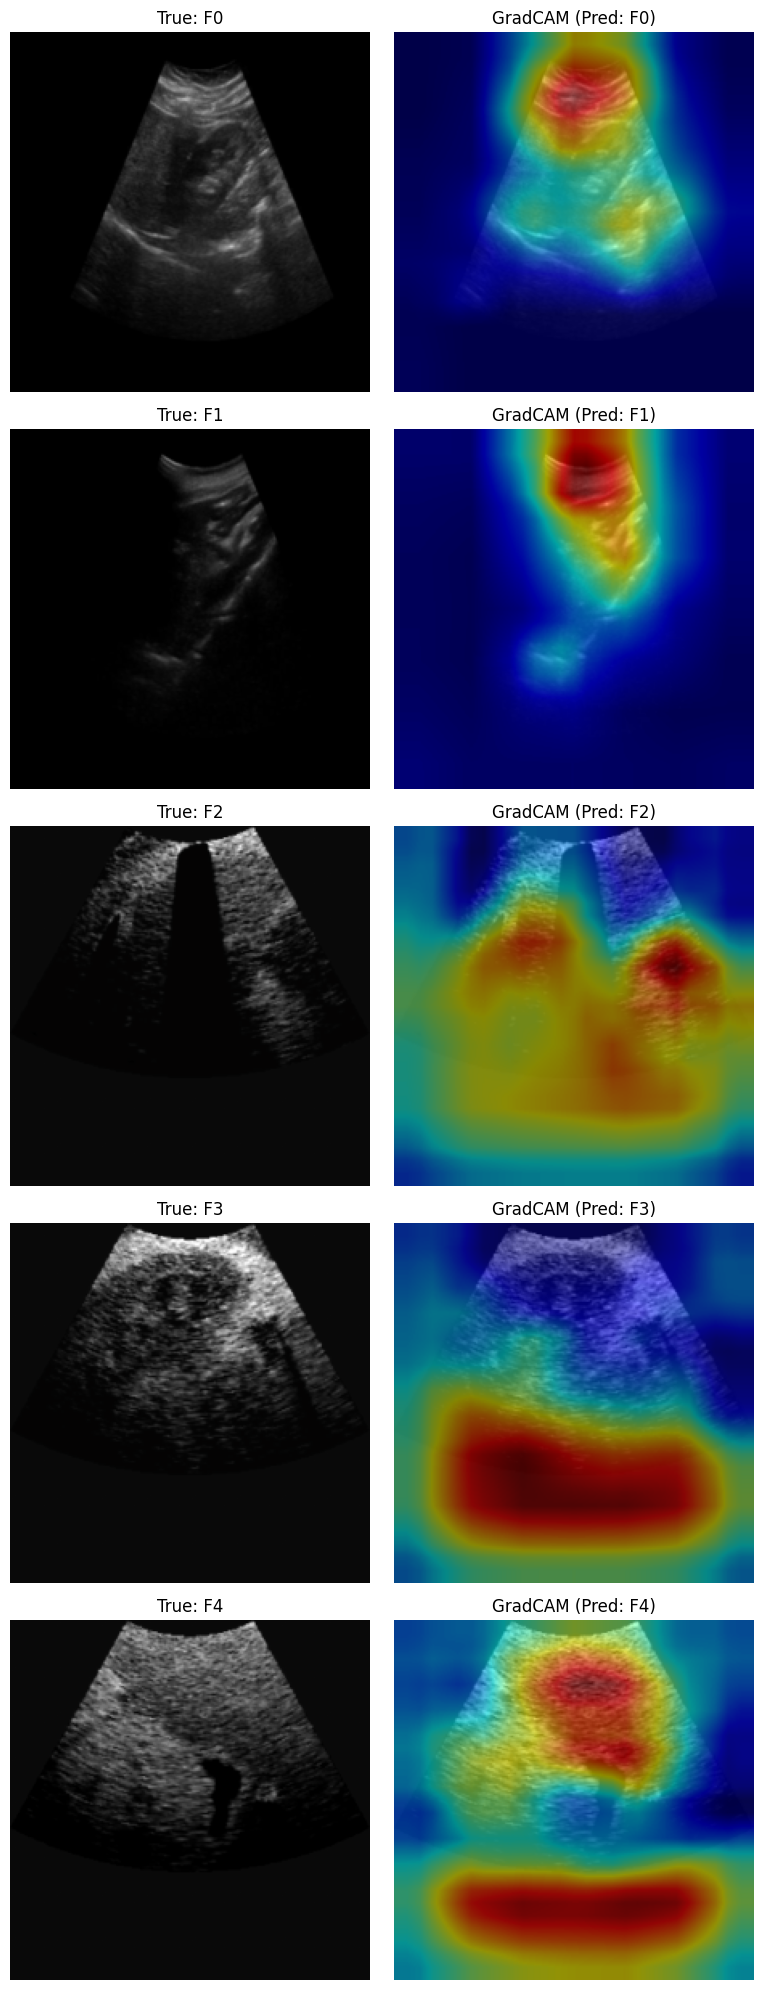


  Visualization: MedViT Base  


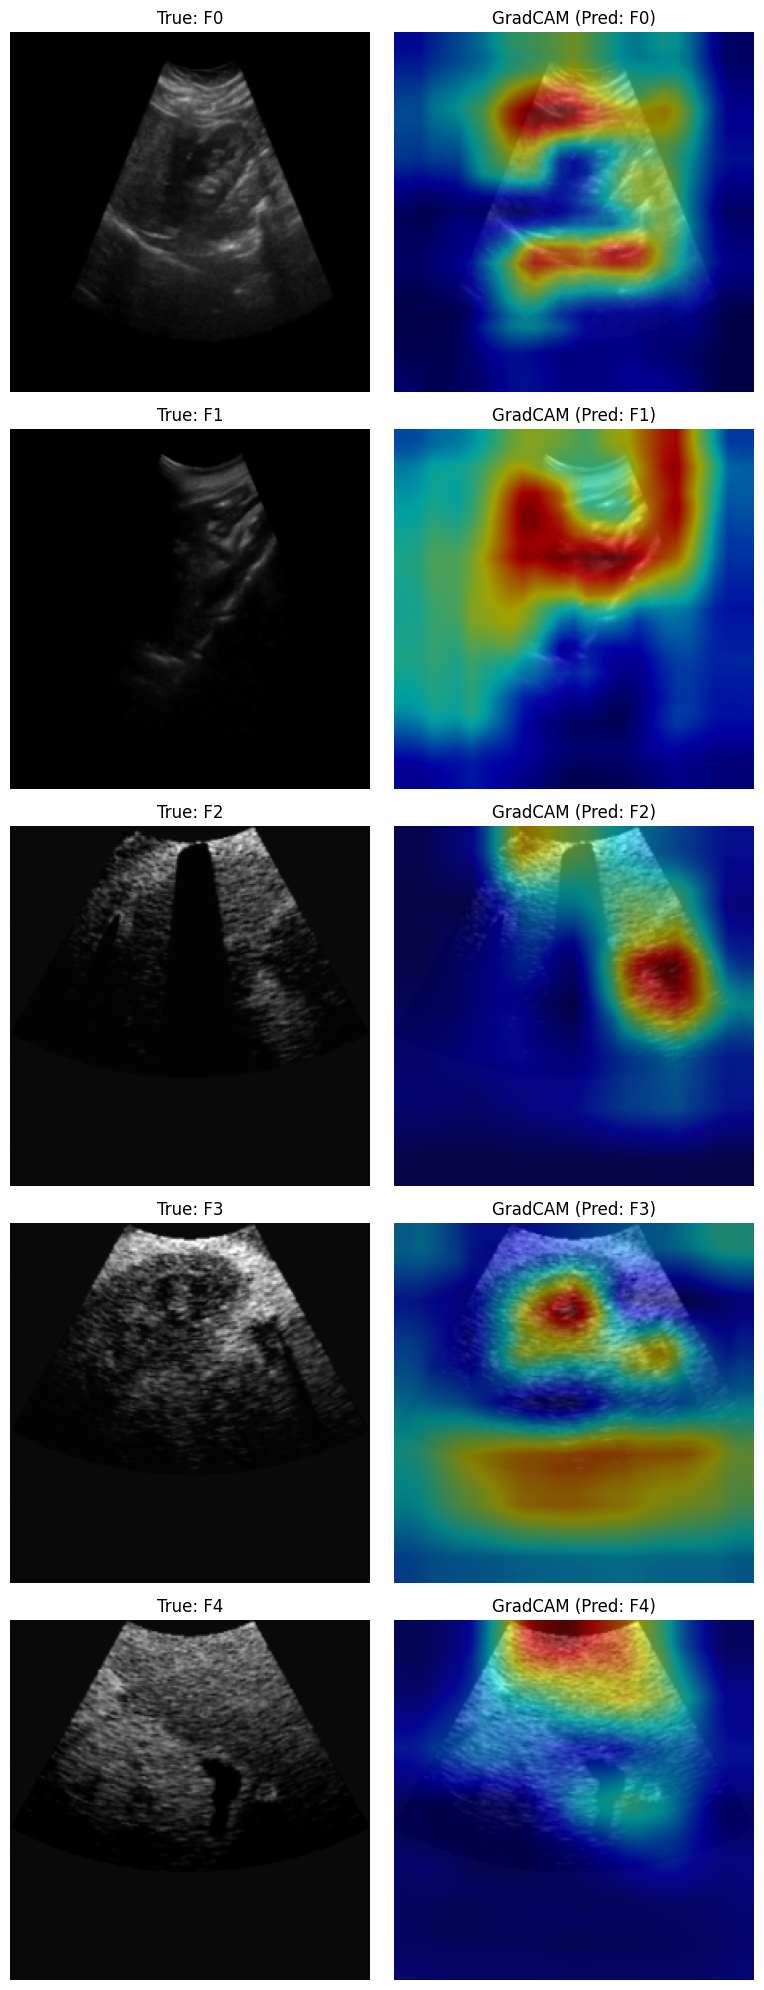


  Visualization: MedViT Large 


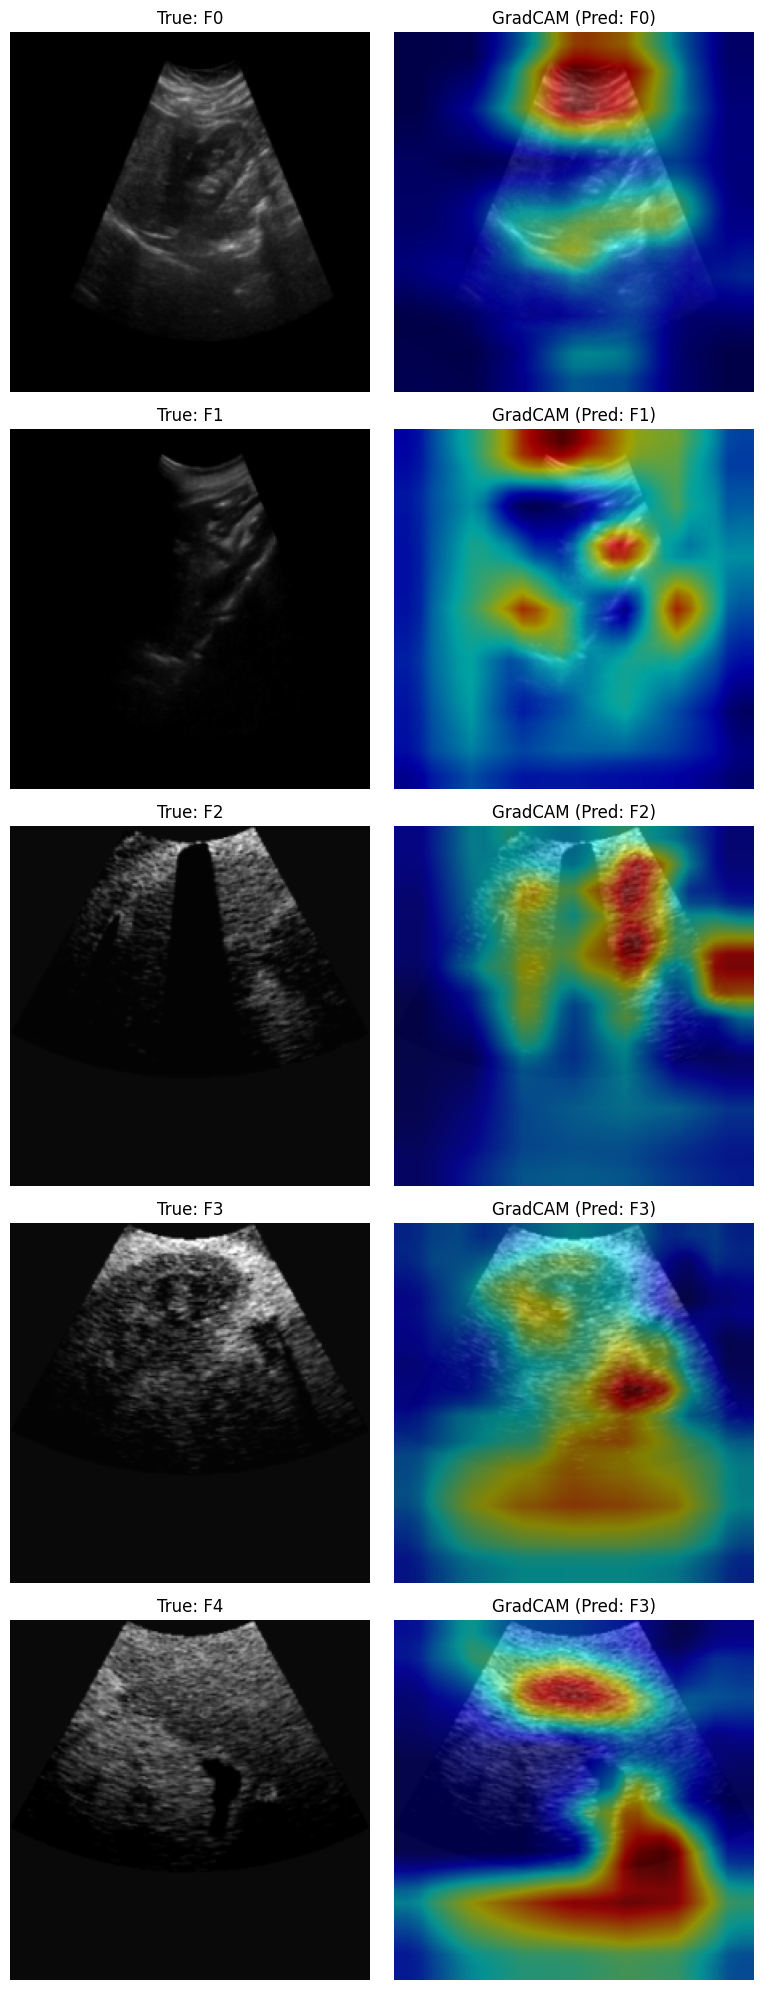

In [7]:
sample_images = []
sample_labels = []
seen_classes = set()

for imgs, lbls in loader_test:
    for i in range(len(lbls)):
        lbl = lbls[i].item()
        if lbl not in seen_classes:
            seen_classes.add(lbl)
            sample_images.append(imgs[i])
            sample_labels.append(lbls[i])
        if len(seen_classes) == num_classes:
            break
    if len(seen_classes) == num_classes:
        break

images = torch.stack(sample_images)
labels = torch.stack(sample_labels)

print("==============================")
print("  Visualization: MedViT Small ")
print("==============================")
target_layers_small = [model_small.features[-1].norm2, model_small.features[-4].norm2, model_small.norm]
process_and_display_cam(model_small, target_layers_small, images, labels)

print("\n==============================")
print("  Visualization: MedViT Base  ")
print("==============================")
target_layers_base = [model_base.features[-1].norm2, model_base.features[-4].norm2, model_base.norm]
process_and_display_cam(model_base, target_layers_base, images, labels)

print("\n==============================")
print("  Visualization: MedViT Large ")
print("==============================")
target_layers_large = [model_large.features[-1].norm2, model_large.features[-4].norm2, model_large.norm]
process_and_display_cam(model_large, target_layers_large, images, labels)